In [1]:
%pip install -q kaggle

Note: you may need to restart the kernel to use updated packages.


In [2]:
!kaggle datasets download -d uciml/iris

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0




  0%|          | 0.00/3.60k [00:00<?, ?B/s]
100%|██████████| 3.60k/3.60k [00:00<?, ?B/s]


In [3]:
import zipfile

# Extract the content of the zip file in the same directory
with zipfile.ZipFile('iris.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

## Preprocessing

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv('Iris.csv')
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
17,18,5.1,3.5,1.4,0.3,Iris-setosa
56,57,6.3,3.3,4.7,1.6,Iris-versicolor
69,70,5.6,2.5,3.9,1.1,Iris-versicolor
21,22,5.1,3.7,1.5,0.4,Iris-setosa
54,55,6.5,2.8,4.6,1.5,Iris-versicolor


In [6]:
# drop id column as its not need for classification
df.drop('Id', axis=1, inplace=True)

In [7]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
115,6.4,3.2,5.3,2.3,Iris-virginica
89,5.5,2.5,4.0,1.3,Iris-versicolor
71,6.1,2.8,4.0,1.3,Iris-versicolor
51,6.4,3.2,4.5,1.5,Iris-versicolor
82,5.8,2.7,3.9,1.2,Iris-versicolor


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [9]:
# check for duplicate values
df.duplicated().sum()

np.int64(3)

In [10]:
# drop duplicate values if any
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# one-hot encoding for species column and don't prefix the column names with species name, as it is not needed for classification
df = pd.get_dummies(df, columns=['Species'], prefix='', prefix_sep='')

In [13]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Iris-setosa,Iris-versicolor,Iris-virginica
11,4.8,3.4,1.6,0.2,True,False,False
17,5.1,3.5,1.4,0.3,True,False,False
120,6.9,3.2,5.7,2.3,False,False,True
69,5.6,2.5,3.9,1.1,False,True,False
59,5.2,2.7,3.9,1.4,False,True,False


In [14]:
df['Iris-setosa'] = df['Iris-setosa'].astype(int)
df['Iris-versicolor'] = df['Iris-versicolor'].astype(int)
df['Iris-virginica'] = df['Iris-virginica'].astype(int)
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Iris-setosa,Iris-versicolor,Iris-virginica
123,6.3,2.7,4.9,1.8,0,0,1
30,4.8,3.1,1.6,0.2,1,0,0
90,5.5,2.6,4.4,1.2,0,1,0
104,6.5,3.0,5.8,2.2,0,0,1
44,5.1,3.8,1.9,0.4,1,0,0


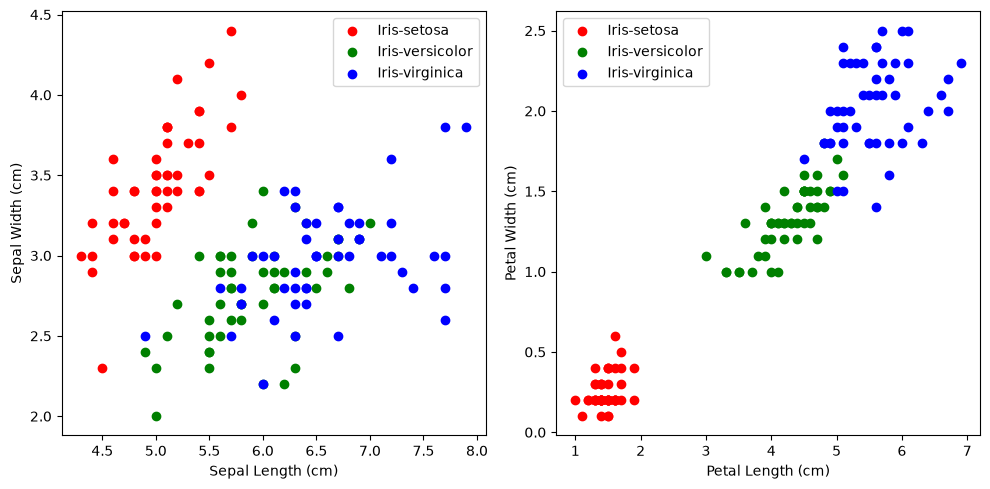

In [15]:
# characteristics of different species of iris flowers using scatter plots.
plt.figure(figsize=(10, 5))

# Scatter plot for Sepal Length vs Sepal Width
plt.subplot(1, 2, 1)
plt.scatter(df[df['Iris-setosa'] == 1]['SepalLengthCm'], df[df['Iris-setosa'] == 1]['SepalWidthCm'], color='red', label='Iris-setosa')
plt.scatter(df[df['Iris-versicolor'] == 1]['SepalLengthCm'], df[df['Iris-versicolor'] == 1]['SepalWidthCm'], color='green', label='Iris-versicolor')
plt.scatter(df[df['Iris-virginica'] == 1]['SepalLengthCm'], df[df['Iris-virginica'] == 1]['SepalWidthCm'], color='blue', label='Iris-virginica')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')

plt.legend()

# Scatter plot for Petal Length vs Petal Width
plt.subplot(1, 2, 2)
plt.scatter(df[df['Iris-setosa'] == 1]['PetalLengthCm'], df[df['Iris-setosa'] == 1]['PetalWidthCm'], color='red', label='Iris-setosa')
plt.scatter(df[df['Iris-versicolor'] == 1]['PetalLengthCm'], df[df['Iris-versicolor'] == 1]['PetalWidthCm'], color='green', label='Iris-versicolor')
plt.scatter(df[df['Iris-virginica'] == 1]['PetalLengthCm'], df[df['Iris-virginica'] == 1]['PetalWidthCm'], color='blue', label='Iris-virginica')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

plt.legend()
plt.tight_layout()  


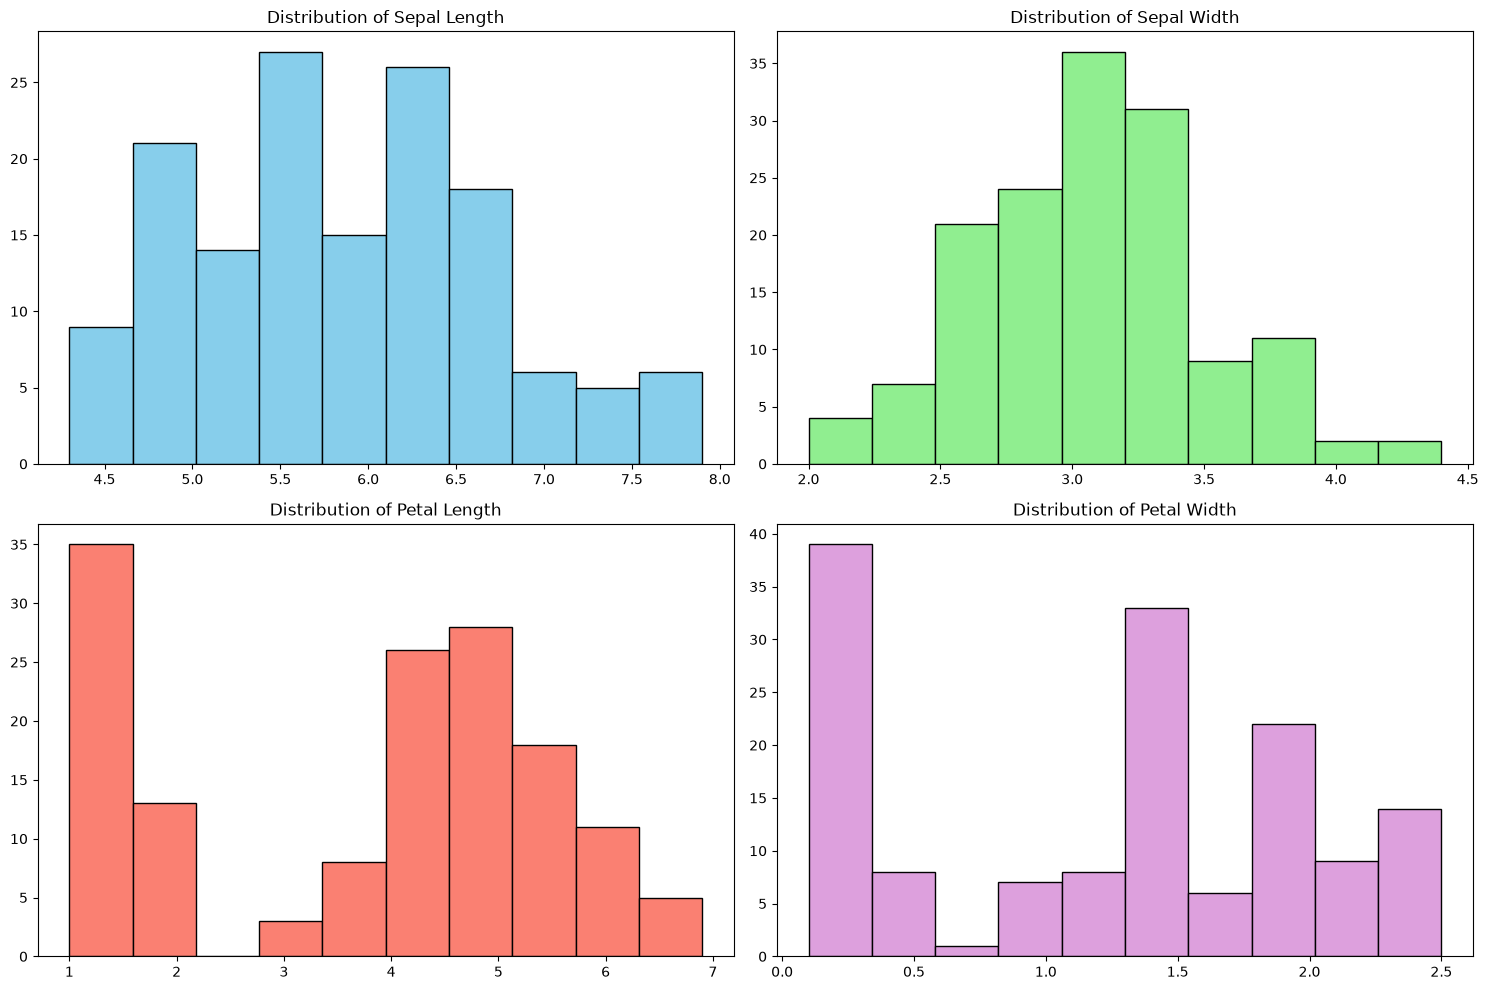

In [16]:
# distribution of each column in the dataset using histograms.
plt.figure(figsize=(15, 10))

# Histogram for Sepal Length
plt.subplot(2, 2, 1)
plt.hist(df['SepalLengthCm'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Sepal Length')

# Histogram for Sepal Width
plt.subplot(2, 2, 2)
plt.hist(df['SepalWidthCm'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Distribution of Sepal Width')

# Histogram for Petal Length
plt.subplot(2, 2, 3)
plt.hist(df['PetalLengthCm'], bins=10, color='salmon', edgecolor='black')
plt.title('Distribution of Petal Length')

# Histogram for Petal Width
plt.subplot(2, 2, 4)
plt.hist(df['PetalWidthCm'], bins=10, color='plum', edgecolor='black')
plt.title('Distribution of Petal Width')

plt.tight_layout()


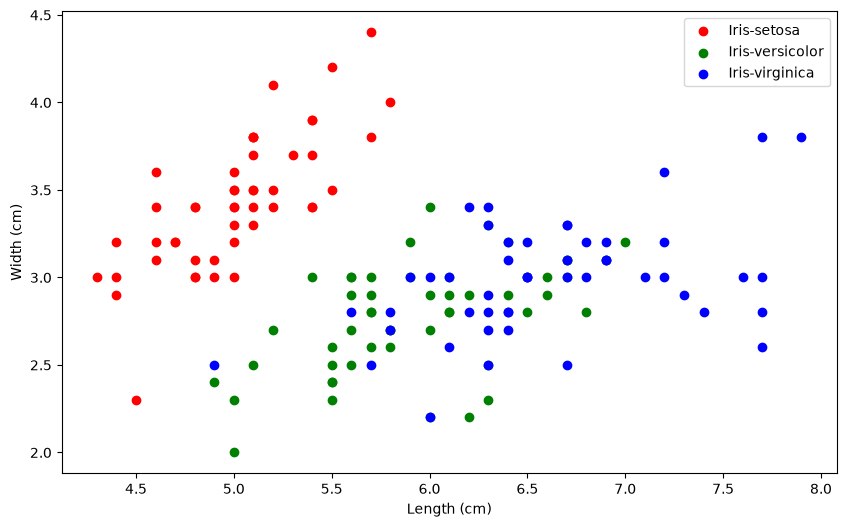

In [17]:
# plot all the datapoints of different species of iris flowers on a graph
plt.figure(figsize=(10, 6))
plt.scatter(df[df['Iris-setosa'] == 1]['SepalLengthCm'], df[df['Iris-setosa'] == 1]['SepalWidthCm'], color='red', label='Iris-setosa')
plt.scatter(df[df['Iris-versicolor'] == 1]['SepalLengthCm'],
    df[df['Iris-versicolor'] == 1]['SepalWidthCm'], color='green', label='Iris-versicolor')
plt.scatter(df[df['Iris-virginica'] == 1]['SepalLengthCm'],
    df[df['Iris-virginica'] == 1]['SepalWidthCm'], color='blue', label='Iris-virginica')

plt.xlabel('Length (cm)')
plt.ylabel('Width (cm)')
plt.legend()
            
plt.xlabel('Length (cm)')
plt.ylabel('Width (cm)')
plt.legend()
            

## Model training and evaluation

In [18]:
# train-test split
from sklearn.model_selection import train_test_split

X = df.drop(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], axis=1)
y = df[['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# KNN classifier
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn.score(X_test, y_test)


0.9333333333333333

In [21]:
# classification report for KNN
from sklearn.metrics import classification_report

knn_predictions = knn.predict(X_test)
print(classification_report(
    y_test.values.argmax(axis=1),
    knn_predictions.argmax(axis=1),
    target_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
))


                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [22]:
# SVM classifier
from sklearn.svm import SVC

svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train.values.argmax(axis=1))
svm.score(X_test, y_test.values.argmax(axis=1))

a:\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


0.9666666666666667

In [23]:
# classification report for SVM
svm_predictions = svm.predict(X_test)
print(classification_report(y_test.values.argmax(axis=1), svm_predictions, target_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.90      1.00      0.95         9

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.96        30
   weighted avg       0.97      0.97      0.97        30

